# Web Scraping and Clustering Analysis for Spam Detection

In [10]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import time
import warnings
warnings.filterwarnings('ignore')

Starting to scrape 50 pages...
Scraping page 1: https://lifehacker.com/tech/page/1
Scraping page 2: https://lifehacker.com/tech/page/2
Scraping page 3: https://lifehacker.com/tech/page/3
Scraping page 4: https://lifehacker.com/tech/page/4
Scraping page 5: https://lifehacker.com/tech/page/5
Scraping page 6: https://lifehacker.com/tech/page/6
Scraping page 7: https://lifehacker.com/tech/page/7
Scraping page 8: https://lifehacker.com/tech/page/8
Scraping page 9: https://lifehacker.com/tech/page/9
Scraping page 10: https://lifehacker.com/tech/page/10
Scraping page 11: https://lifehacker.com/tech/page/11
Scraping page 12: https://lifehacker.com/tech/page/12
Scraping page 13: https://lifehacker.com/tech/page/13
Scraping page 14: https://lifehacker.com/tech/page/14
Scraping page 15: https://lifehacker.com/tech/page/15
Scraping page 16: https://lifehacker.com/tech/page/16
Scraping page 17: https://lifehacker.com/tech/page/17
Scraping page 18: https://lifehacker.com/tech/page/18
Scraping page 1

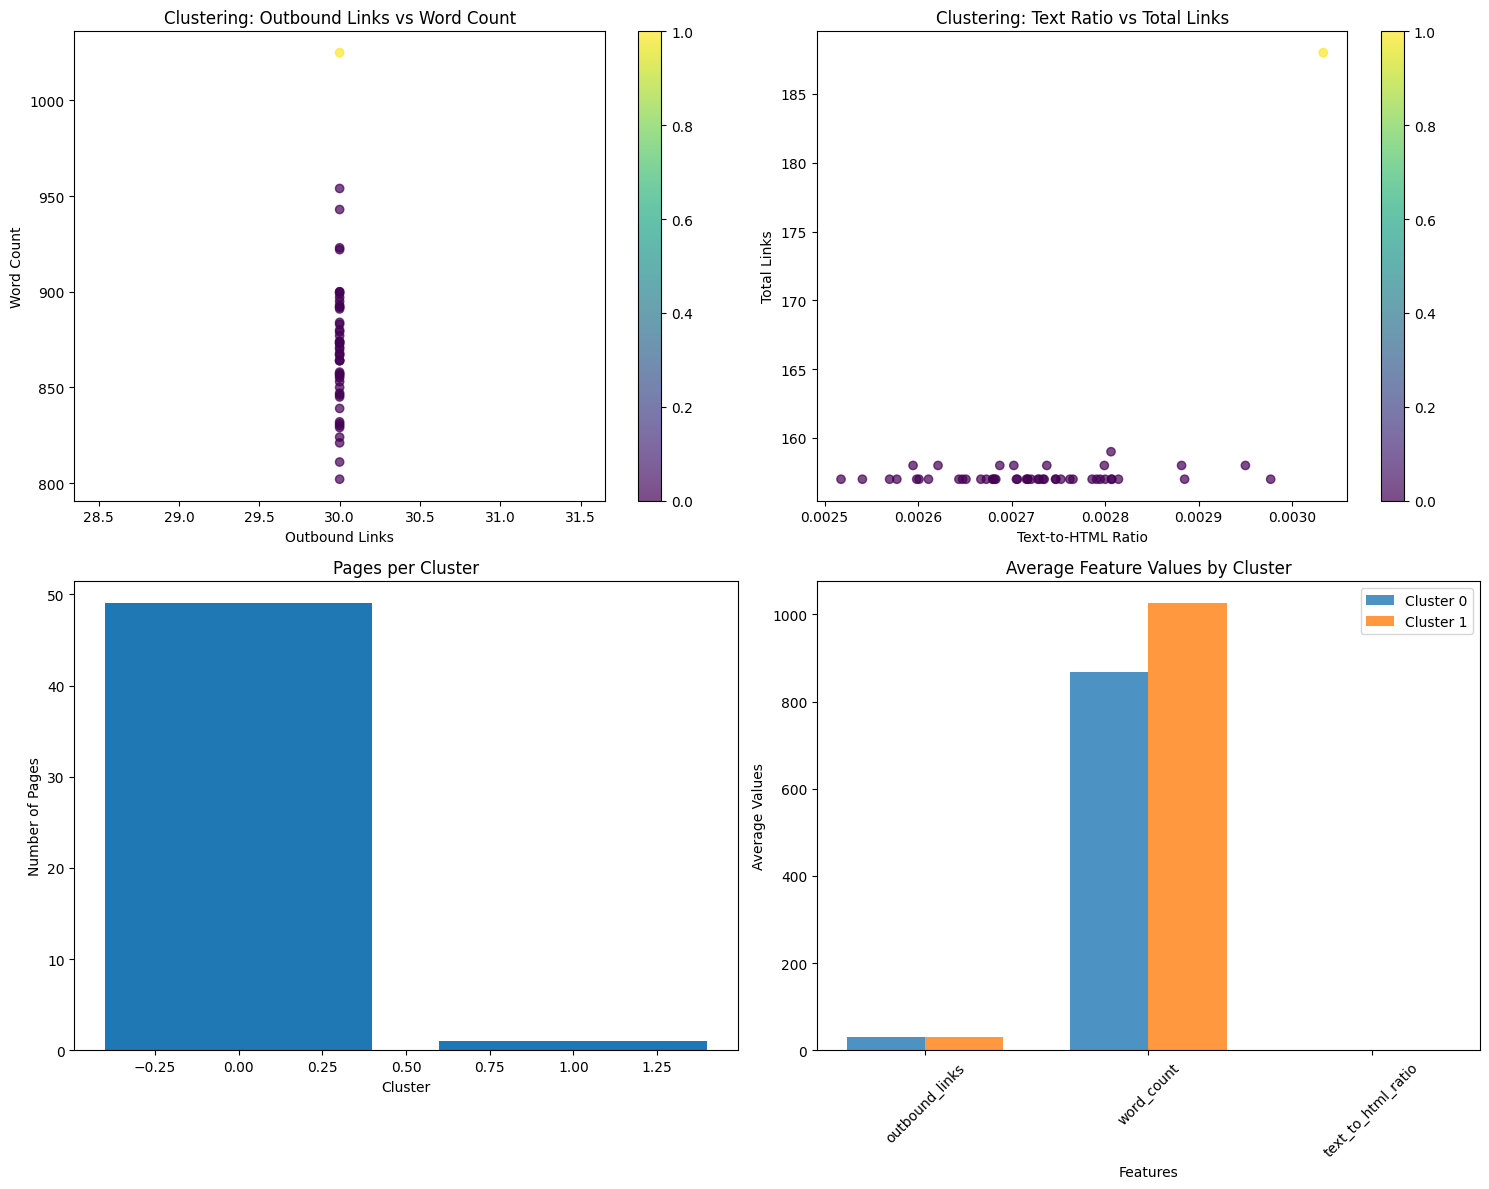

Results saved to lifehacker_blogs_analysis_detailed_results.csv and lifehacker_blogs_analysis_cluster_summary.csv

=== FINAL SUMMARY ===
Total pages analyzed: 50
Pages in Cluster 0: 49
Pages in Cluster 1: 1

Sample pages from each cluster:

Cluster 1 samples:
  Page 1: 1025 words, 30 outbound links

Cluster 0 samples:
  Page 2: 895 words, 30 outbound links
  Page 3: 864 words, 30 outbound links
  Page 4: 943 words, 30 outbound links


In [11]:
class WebPageAnalyzer:
    def __init__(self, base_url_pattern):
        self.base_url_pattern = base_url_pattern
        self.pages_data = []
        self.features_df = None
        self.clustered_df = None
        
    def scrape_pages(self, num_pages=50):
        print(f"Starting to scrape {num_pages} pages...")
        
        for page_num in range(1, num_pages + 1):
            try:
                url = self.base_url_pattern.format(page=page_num)
                print(f"Scraping page {page_num}: {url}")
                
                headers = {
                    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
                }
                
                response = requests.get(url, headers=headers)
                response.raise_for_status()
                
                page_data = {
                    'page_number': page_num,
                    'url': url,
                    'html_content': response.text,
                    'status_code': response.status_code
                }
                
                self.pages_data.append(page_data)
                
                # Delay between requests
                time.sleep(1)
                
            except Exception as e:
                print(f"Error scraping page {page_num}: {str(e)}")
                # Empty entry to maintain page numbering
                self.pages_data.append({
                    'page_number': page_num,
                    'url': url if 'url' in locals() else '',
                    'html_content': '',
                    'status_code': 0,
                    'error': str(e)
                })
        
        print(f"Scraping completed. Successfully scraped {len([p for p in self.pages_data if p.get('html_content')])} pages.")
    
    def extract_features(self):
        print("Extracting features from scraped pages...")
        
        features_list = []
        
        for page_data in self.pages_data:
            if not page_data.get('html_content'):
                continue
                
            try:
                soup = BeautifulSoup(page_data['html_content'], 'html.parser')
                
                # Extracting outbound links
                all_links = soup.find_all('a', href=True)
                base_domain = self._extract_domain(page_data['url'])
                outbound_links = [link for link in all_links 
                                if link['href'].startswith('http') 
                                and base_domain not in link['href']]
                outbound_count = len(outbound_links)
                
                # Extracting main text content
                # Removing script and style elements
                for script in soup(["script", "style"]):
                    script.decompose()
                
                text_content = soup.get_text()
                words = re.findall(r'\b\w+\b', text_content.lower())
                word_count = len(words)
                
                # Finding most common words (excluding common stop words)
                stop_words = {'the', 'a', 'an', 'and', 'or', 'but', 'in', 'on', 'at', 'to', 'for', 'of', 'with', 'by', 'is', 'are', 'was', 'were', 'be', 'been', 'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could', 'should', 'may', 'might', 'must', 'can', 'this', 'that', 'these', 'those', 'i', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'him', 'her', 'us', 'them'}
                filtered_words = [word for word in words if word not in stop_words and len(word) > 2]
                
                if filtered_words:
                    word_freq = Counter(filtered_words)
                    most_common_word, most_common_count = word_freq.most_common(1)[0]
                else:
                    most_common_word, most_common_count = '', 0
                
                # Additional features for spam detection
                title = soup.find('title')
                title_text = title.get_text() if title else ''
                title_length = len(title_text)
                
                img_count = len(soup.find_all('img'))
                form_count = len(soup.find_all('form'))
                input_count = len(soup.find_all('input'))
                
                # Calculating text-to-HTML ratio
                html_size = len(page_data['html_content'])
                text_to_html_ratio = word_count / html_size if html_size > 0 else 0
                
                # Counting internal links
                internal_links = [link for link in all_links 
                                if not link['href'].startswith('http') or base_domain in link['href']]
                internal_link_count = len(internal_links)
                
                features = {
                    'page_number': page_data['page_number'],
                    'url': page_data['url'],
                    'outbound_links': outbound_count,
                    'word_count': word_count,
                    'most_common_word': most_common_word,
                    'most_common_count': most_common_count,
                    'title_length': title_length,
                    'img_count': img_count,
                    'form_count': form_count,
                    'input_count': input_count,
                    'text_to_html_ratio': text_to_html_ratio,
                    'internal_links': internal_link_count,
                    'total_links': len(all_links),
                    'html_size': html_size
                }
                
                features_list.append(features)
                
            except Exception as e:
                print(f"Error extracting features from page {page_data['page_number']}: {str(e)}")
        
        self.features_df = pd.DataFrame(features_list)
        print(f"Feature extraction completed for {len(features_list)} pages.")
        return self.features_df
    
    def _extract_domain(self, url):
        from urllib.parse import urlparse
        return urlparse(url).netloc
    
    def perform_clustering(self, n_clusters=2):
        if self.features_df is None:
            raise ValueError("Features not extracted yet. Run extract_features() first.")
        
        print(f"Performing K-means clustering with {n_clusters} clusters...")
        
        # Selecting numerical features for clustering
        numerical_features = [
            'outbound_links', 'word_count', 'most_common_count', 
            'title_length', 'img_count', 'form_count', 'input_count',
            'text_to_html_ratio', 'internal_links', 'total_links', 'html_size'
        ]
        
        clustering_data = self.features_df[numerical_features].fillna(0)
        
        # Standardizing features
        scaler = StandardScaler()
        scaled_features = scaler.fit_transform(clustering_data)
        
        # Clustering
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        clusters = kmeans.fit_predict(scaled_features)
        
        # Adding cluster labels to dataframe
        self.clustered_df = self.features_df.copy()
        self.clustered_df['cluster'] = clusters
        
        # Calculating silhouette score
        silhouette_avg = silhouette_score(scaled_features, clusters)
        print(f"Silhouette Score: {silhouette_avg:.3f}")
        
        # Storing clustering objects for analysis
        self.scaler = scaler
        self.kmeans = kmeans
        self.scaled_features = scaled_features
        
        return self.clustered_df
    
    def analyze_clusters(self):
        if self.clustered_df is None:
            raise ValueError("Clustering not performed yet. Run perform_clustering() first.")
        
        print("=== CLUSTER ANALYSIS ===")
        
        cluster_stats = self.clustered_df.groupby('cluster').agg({
            'outbound_links': ['mean', 'std'],
            'word_count': ['mean', 'std'],
            'most_common_count': ['mean', 'std'],
            'title_length': ['mean', 'std'],
            'text_to_html_ratio': ['mean', 'std'],
            'total_links': ['mean', 'std']
        }).round(2)
        
        print("\nCluster Statistics:")
        print(cluster_stats)
        
        spam_indicators = {}
        
        for cluster_id in self.clustered_df['cluster'].unique():
            cluster_data = self.clustered_df[self.clustered_df['cluster'] == cluster_id]
            
            # Calculating spam indicators
            avg_outbound = cluster_data['outbound_links'].mean()
            avg_word_count = cluster_data['word_count'].mean()
            avg_text_ratio = cluster_data['text_to_html_ratio'].mean()
            avg_total_links = cluster_data['total_links'].mean()
            
            # Spam scoring
            spam_score = 0
            reasons = []
            
            # High outbound links might indicate link farms
            if avg_outbound > self.clustered_df['outbound_links'].mean() + self.clustered_df['outbound_links'].std():
                spam_score += 2
                reasons.append("High outbound links")
            
            # Very low word count might indicate thin content
            if avg_word_count < self.clustered_df['word_count'].mean() - self.clustered_df['word_count'].std():
                spam_score += 2
                reasons.append("Low word count (thin content)")
            
            # Very low text-to-HTML ratio might indicate excessive markup
            if avg_text_ratio < 0.01:
                spam_score += 1
                reasons.append("Low text-to-HTML ratio")
            
            # Excessive total links
            if avg_total_links > self.clustered_df['total_links'].mean() + 2 * self.clustered_df['total_links'].std():
                spam_score += 1
                reasons.append("Excessive total links")
            
            spam_indicators[cluster_id] = {
                'spam_score': spam_score,
                'reasons': reasons,
                'page_count': len(cluster_data),
                'avg_outbound_links': avg_outbound,
                'avg_word_count': avg_word_count,
                'avg_text_ratio': avg_text_ratio
            }
        
        print("\n=== SPAM DETECTION ANALYSIS ===")
        for cluster_id, indicators in spam_indicators.items():
            print(f"\nCluster {cluster_id}:")
            print(f"  Pages: {indicators['page_count']}")
            print(f"  Spam Score: {indicators['spam_score']}/6")
            print(f"  Average Outbound Links: {indicators['avg_outbound_links']:.1f}")
            print(f"  Average Word Count: {indicators['avg_word_count']:.1f}")
            print(f"  Average Text Ratio: {indicators['avg_text_ratio']:.4f}")
            
            if indicators['spam_score'] >= 3:
                print(f"  ⚠️ POTENTIAL SPAM CLUSTER")
                print(f"  Reasons: {', '.join(indicators['reasons'])}")
            elif indicators['spam_score'] >= 1:
                print(f"  ⚠️ SUSPICIOUS CHARACTERISTICS")
                print(f"  Reasons: {', '.join(indicators['reasons'])}")
            else:
                print(f"  ✅ Appears normal")
        
        return spam_indicators
    
    def visualize_clusters(self):
        if self.clustered_df is None:
            raise ValueError("Clustering not performed yet.")
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. Outbound Links vs Word Count
        scatter = axes[0,0].scatter(self.clustered_df['outbound_links'], 
                                  self.clustered_df['word_count'], 
                                  c=self.clustered_df['cluster'], 
                                  cmap='viridis', alpha=0.7)
        axes[0,0].set_xlabel('Outbound Links')
        axes[0,0].set_ylabel('Word Count')
        axes[0,0].set_title('Clustering: Outbound Links vs Word Count')
        plt.colorbar(scatter, ax=axes[0,0])
        
        # 2. Text-to-HTML Ratio vs Total Links
        scatter2 = axes[0,1].scatter(self.clustered_df['text_to_html_ratio'], 
                                    self.clustered_df['total_links'], 
                                    c=self.clustered_df['cluster'], 
                                    cmap='viridis', alpha=0.7)
        axes[0,1].set_xlabel('Text-to-HTML Ratio')
        axes[0,1].set_ylabel('Total Links')
        axes[0,1].set_title('Clustering: Text Ratio vs Total Links')
        plt.colorbar(scatter2, ax=axes[0,1])
        
        # 3. Cluster distribution
        cluster_counts = self.clustered_df['cluster'].value_counts().sort_index()
        axes[1,0].bar(cluster_counts.index, cluster_counts.values)
        axes[1,0].set_xlabel('Cluster')
        axes[1,0].set_ylabel('Number of Pages')
        axes[1,0].set_title('Pages per Cluster')
        
        # 4. Feature comparison across clusters
        features_to_compare = ['outbound_links', 'word_count', 'text_to_html_ratio']
        cluster_means = self.clustered_df.groupby('cluster')[features_to_compare].mean()
        
        x = np.arange(len(features_to_compare))
        width = 0.35
        
        for i, cluster_id in enumerate(cluster_means.index):
            axes[1,1].bar(x + i*width, cluster_means.loc[cluster_id], 
                         width, label=f'Cluster {cluster_id}', alpha=0.8)
        
        axes[1,1].set_xlabel('Features')
        axes[1,1].set_ylabel('Average Values')
        axes[1,1].set_title('Average Feature Values by Cluster')
        axes[1,1].set_xticks(x + width/2)
        axes[1,1].set_xticklabels(features_to_compare, rotation=45)
        axes[1,1].legend()
        
        plt.tight_layout()
        plt.show()
    
    def save_results(self, filename_prefix='web_analysis'):
        if self.clustered_df is not None:
            # Save detailed results
            self.clustered_df.to_csv(f'{filename_prefix}_detailed_results.csv', index=False)
            
            # Save summary statistics
            summary_stats = self.clustered_df.groupby('cluster').agg({
                'page_number': 'count',
                'outbound_links': ['mean', 'std', 'min', 'max'],
                'word_count': ['mean', 'std', 'min', 'max'],
                'most_common_count': ['mean', 'std'],
                'text_to_html_ratio': ['mean', 'std'],
                'total_links': ['mean', 'std']
            }).round(3)
            
            summary_stats.to_csv(f'{filename_prefix}_cluster_summary.csv')
            
            print(f"Results saved to {filename_prefix}_detailed_results.csv and {filename_prefix}_cluster_summary.csv")


BASE_URL_PATTERN = "https://lifehacker.com/tech/page/{page}"

analyzer = WebPageAnalyzer(BASE_URL_PATTERN)
analyzer.scrape_pages(num_pages=50)
features_df = analyzer.extract_features()
print("Sample of extracted features:")
print(features_df.head())
clustered_df = analyzer.perform_clustering(n_clusters=2)
spam_analysis = analyzer.analyze_clusters()
analyzer.visualize_clusters()
analyzer.save_results('lifehacker_blogs_analysis')

print("\n=== FINAL SUMMARY ===")
print(f"Total pages analyzed: {len(clustered_df)}")
print(f"Pages in Cluster 0: {len(clustered_df[clustered_df['cluster'] == 0])}")
print(f"Pages in Cluster 1: {len(clustered_df[clustered_df['cluster'] == 1])}")

print("\nSample pages from each cluster:")
for cluster_id in clustered_df['cluster'].unique():
    print(f"\nCluster {cluster_id} samples:")
    cluster_samples = clustered_df[clustered_df['cluster'] == cluster_id].head(3)
    for _, row in cluster_samples.iterrows():
        print(f"  Page {row['page_number']}: {row['word_count']} words, {row['outbound_links']} outbound links")